## DataBase Types

Choosing the right database is one of the most critical decisions you’ll make in a system design interview.The database you pick often dictates how well your system performs under load, how easily it scales, and how gracefully it handles complexity in real-world scenarios.

### Relational
A Relational Database stores data in structured tables with rows and columns. It’s like an Excel sheet, but much more powerful.
Each table represents an entity (like Users, Orders, or Products), and relationships between tables are defined using foreign keys. It uses SQL (Structured Query Language) to query and manipulate data.

#### When to use it
1. Your data is structured and relational : 
Relational databases are ideal when your data consists of clearly defined entities with strong relationships.
2. You need strong consistency : 
Relational databases provide full ACID compliance, ensuring reliable transactions.
3. You require complex queries and reporting: Relational databases provide SQL, a powerful and expressive query language. SQL supports filtering, aggregation, grouping, and multi-table joins.

#### Design Considerations:
1. Indexing: Indexes speed up read-heavy queries by allowing the database to quickly locate rows.
Create indexes on frequently queried columns (e.g., user_id, email). Use composite indexes for multi-column filters. Avoid over-indexing in write-heavy systems, as it can slow down inserts and updates.
2. Joins: Joins are powerful for analytics and reporting. However, avoid excessive joins on large tables as they can become performance bottlenecks. Never design for cross-shard joins unless absolutely necessary.
3. Sharding: Sharding enables horizontal scaling but introduces complexity.
Choose high-cardinality shard keys (e.g., user_id) to distribute load evenly. Be mindful that cross-shard queries and transactions are difficult to implement.

#### Example Databases: 
1. PostgreSQL – Open-source, feature-rich, ACID-compliant
2. MySQL – Widely used, especially in LAMP stack applications
3. Oracle DB – Enterprise-grade RDBMS

### In-Memory: 
An In-Memory Database stores data directly in RAM instead of disk. This makes it blazingly fast for read and write operations

#### When to use it
1. You need ultra-low latency: In-memory databases are ideal for applications that demand near-instantaneous responses.
2. The data is temporary or can be regenerated: In-memory databases are great for storing data that can be recomputed if lost.
3. You want to reduce load on your main database

#### Design Considerations
1. Volatility: Since RAM is volatile, data is lost on crash or restart unless persistence is enable

Tools like Redis offer optional persistence via: a. RDB (snapshotting): Saves data at intervals
b. AOF (Append Only File): Logs each write operation
2. Eviction Policies: RAM is fast, but limited. When memory runs out, older or less-used data is evicted. Common eviction policies include LRU, LFU and TTL.
3. Keep It Lean: Avoid storing large files or infrequently accessed data. Store only hot and frequently accessed data such as user sessions and recent activity.
4. Replication: Replication can improve read performance and provide failover support in case the primary instance goes down. Redis supports replica nodes and automatic failover using Sentinel or Cluster mode. However, replication is typically asynchronous, so there's a risk of data loss if the primary fails before sync. Always persist critical data in a durable system like a relational database.
#### Example databases
1. Redis – Lightning fast, supports data structures like lists, sets, sorted sets, and pub-sub
2. Memcached – Simple key-value store for caching
3. Apache Ignite – Distributed in-memory store with SQL support
4. Hazelcast – Often used in Java-based enterprise applications

### Key-Value
A Key-Value Database is the simplest type of database. It stores data as a collection of key-value pairs, where each key is unique and maps directly to a value. Think of it like a giant, distributed HashMap. There are no tables, schemas, or relationships—just keys and values. This makes key-value stores extremely fast and highly scalable.

#### When to use it
1. You need fast lookups by unique key: Key-value stores offer constant-time (O(1)) reads and writes, making them ideal for quick access using a unique identifier.
2. You don’t need complex queries or relationships: If your data doesn't require joins, filtering, or relational constraints, a key-value store is a simple and scalable choice.
3. You’re dealing with high-volume, low-latency workloads: Key-value stores are designed for massive throughput and are often used in systems that demand millions of reads/writes per second with minimal latency.

#### Design Considerations
1. Lookup-only access: You can only retrieve values by key. They typically don’t provide filtering, sorting, or joining. Secondary indexes are typically not supported.
2. No enforced schema: Key-value databases are schema-less. Values can be strings, JSON, or binary blobs.This gives you flexibility but also puts the burden on your application to handle serialization/deserialization and versioning of the data model.
3. Easy horizontal scaling: Key-based partitioning enables seamless distribution across nodes using consistent hashing or range-based partitioning.

#### Example Databases
1. Redis – Also acts as a key-value store with rich data types
2. Amazon DynamoDB – Managed, horizontally scalable key-value store

### Document
A Document Database stores data as documents, typically in JSON or BSON format. Each document is a self-contained unit with fields and values making it flexible and schema-less.
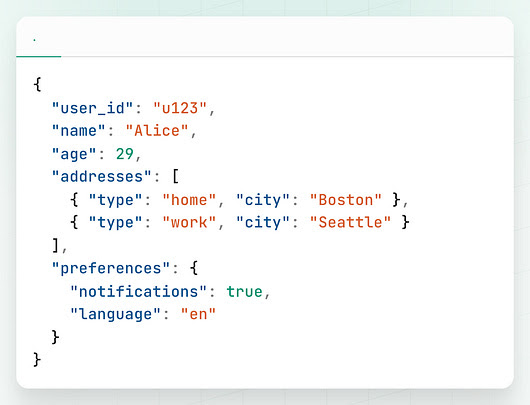

#### When to Use it
1. Data structures vary across records: Document databases are ideal when different records have different fields.
2. You need to store nested or hierarchical data: Document databases make it easy to store deeply nested data supporting complex, embedded objects without joins.
3. You want schema flexibility and fast iteration: Document databases let you evolve your schema without downtime or migrations

#### Design Considerations
1. Indexing: Indexing is crucial for performance but indexing deeply nested fields may add overhead.
Index frequently queried fields (user_id, email, etc.), Use compound indexes for multi-field queries
2. Document Size Limits: Related data is often embedded to avoid joins. This improves read performance but can increases write complexity and risk of duplication.
3. Sharding: Most document databases support horizontal scaling via sharding, but it requires careful design:Use a high-cardinality shard key (e.g., user_id) to avoid skew and hot partitions

#### Example Database
1. MongoDB – The most popular document store, widely used across startups and enterprises
2. Couchbase – Combines key-value and document storage with powerful querying
3. Firebase Firestore – Realtime document database, ideal for mobile/web apps

### Graph
A Graph Database is designed to store and navigate relationships. It represents data as nodes (entities) and edges (relationships between entities). This structure makes it ideal for scenarios where connections are as important as the data itself.

#### When to use it
1. Relationships are central to your data: Graph databases excel when the focus is on how entities are connected.
2. You need traversals or recommendations: Graph databases are optimized for graph traversals, making them ideal for discovering indirect relationships and patterns.
3. You need to run complex relationship queries efficiently: Graph databases are optimized for querying densely connected data like in a social network.

#### Design Considerations
1. Traversal Efficiency: Graph databases handle multiple level of relationships far more efficiently than relational joins. Performance remains stable even with deep traversals.
2. Indexing: While traversals are optimized, indexing is still essential for quickly locating the starting node(s) of a query. Index common node and relationship properties like user_id, email, or timestamp.
3. Schema Flexibility: While schema is optional, consistent labeling (e.g., User, FOLLOWS) helps maintain query clarity and performance.
4. Scalability: Not all graph DBs scale horizontally. For large datasets and high throughput, choose distributed graph databases like: Dgraph, TigerGraph, Neo4j Enterprise.
5. Query Language: Graph databases use domain-specific languages to query and manipulate graph data.

#### Example Databases
1. Neo4j – The most popular graph database, known for its Cypher query language
2. Amazon Neptune – Fully managed graph database supporting both RDF and property graphs
3. ArangoDB – Multi-model (including graph), good for flexible use cases

### Wide-Column
A Wide-Column Database stores data in tables, rows, and columns, but unlike traditional relational databases, each row can have a different set of columns. It’s optimized for large-scale, write-heavy workloads and high-speed data retrieval across massive datasets.

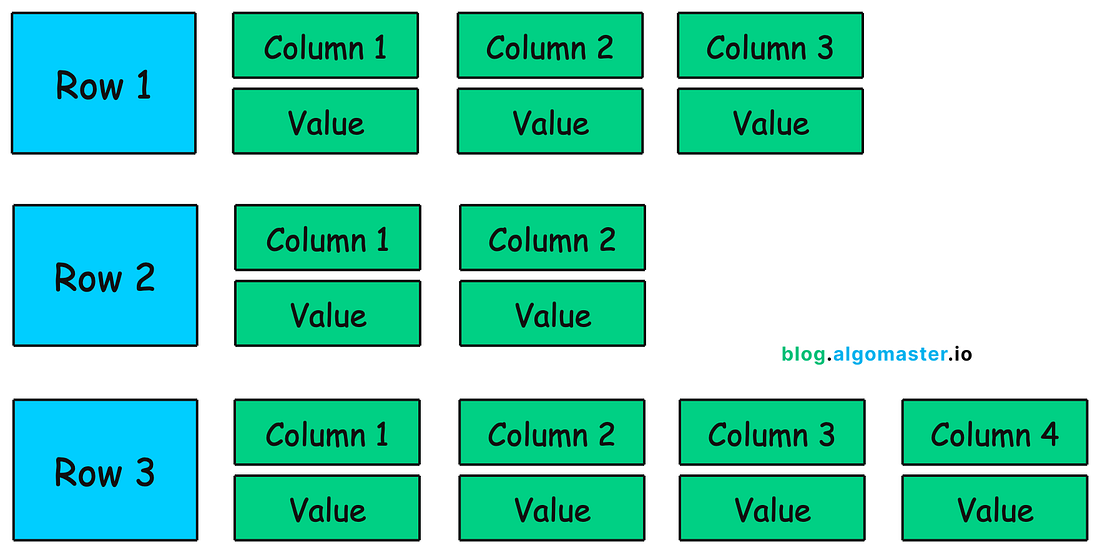

Under the hood, data is stored by column families (groupings of related columns), which allows for fast access to specific columns without scanning entire rows.

#### When to use it
1. You need high write throughput at scale: Wide-column databases are optimized for write-heavy append-only workloads. They can ingest millions of rows per second with minimal latency.
2. Your data grows continuously and at massive scale: Wide-column databases are ideal for storing petabytes of time-partitioned or user-specific data that grows rapidly. Each row can store a different set of columns, allowing for highly flexible and sparse storage.
3. You want fast lookups and flexible row-level schemas: Wide-column stores offer low-latency access to specific rows and columns, making them perfect for read patterns where you know exactly what you want to retrieve.

#### Design Considerations
1. Schema design: In wide-column databases, the most critical part of performance comes down to how you design:
    a. Row keys – Used to identify rows uniquely (e.g., user_id, device_id)
    b. Partition keys – Determines how data is distributed across nodes
    c. Clustering columns – Defines how data is sorted within a partition

2. Denormalization: 
Unlike relational databases, wide-column stores do not support joins efficiently. Instead, you duplicate related data across multiple tables or rows to speed up reads.
3. Indexing: Wide-column databases support primary indexes through: Partition keys (for fast lookups)
Clustering keys (for sorting and range queries within a partition),
Secondary indexes do exist, but often expensive in terms of performance.
4. Sharding and Replication: These databases are designed to automatically handle horizontal sharding and replication. But bad partition keys (e.g., low-cardinality values) can cause hotspots.
5. Tunable consistency: Wide-column databases often support tunable consistency, letting you balance between availability, performance, and data correctness.

#### Example Databases
1. Apache Cassandra – Highly scalable and fault-tolerant; used by Netflix, Instagram
2. ScyllaDB – A high-performance drop-in replacement for Cassandra
3. Google Bigtable – The original wide-column database, used by Google Search and Maps
4. HBase – Hadoop-based, good for big data pipelines

### Time-Series
A Time-Series Database (TSDB) is purpose-built to store, retrieve, and analyze data points that are time-stamped. Every record is tied to a specific moment making it perfect for tracking changes over time.

#### When to use it
1. Data is generated in chronological order: Time-series databases excel when your data is produced in a steady, timestamped flow, often from machines, users, or external systems.
Ex: Monitoring tools like Prometheus track CPU, memory, and network usage every few seconds.
2. You need to perform rollups, aggregations, or downsampling: TSDBs efficiently summarize historical data into trends using rollups (e.g., averages, min/max) and downsampling (e.g., hourly or daily aggregates).
3. You need high write volume with time-bound queries: TSDBs are designed for massive write throughput and queries that are scoped to specific time windows

#### Design Considerations
1. Write-optimized: TSDBs use append-only writes, time-based compression, and sorted storage to support high ingestion rates with minimal disk I/O.
2. Time-based retention: Data is auto-expired based on retention policies.
3. Time as the primary index: In most TSDBs, time is the primary index, which means: Queries scoped by time (e.g., “last 7 days”) are extremely efficient.
4. Downsampling: To manage storage and maintain query performance, it's common to roll up raw data into aggregated summaries over fixed intervals.
5. Sharding: To support horizontal scalability, TSDBs often shard data by: Time ranges (e.g., day/week/month buckets), Series IDs (unique combinations of metric name + tag set)
* Querying across many shards may still be costly if not time-bounded.

#### Example Databases
1. InfluxDB – Popular open-source TSDB with a SQL-like query language
2. TimescaleDB – Built on PostgreSQL; combines relational power with time-series efficiency
3. Prometheus – Widely used in monitoring and observability (e.g., Kubernetes)

### Text-Search
A Text-Search Database is designed to efficiently store, index, and search through large volumes of textual data. It goes beyond simple substring matching by supporting full-text search, ranking, tokenization, stemming, fuzzy matching, and relevance scoring.

Instead of scanning documents line by line, it builds inverted indexes—a map of words to the documents they appear in, allowing lightning-fast text lookups.

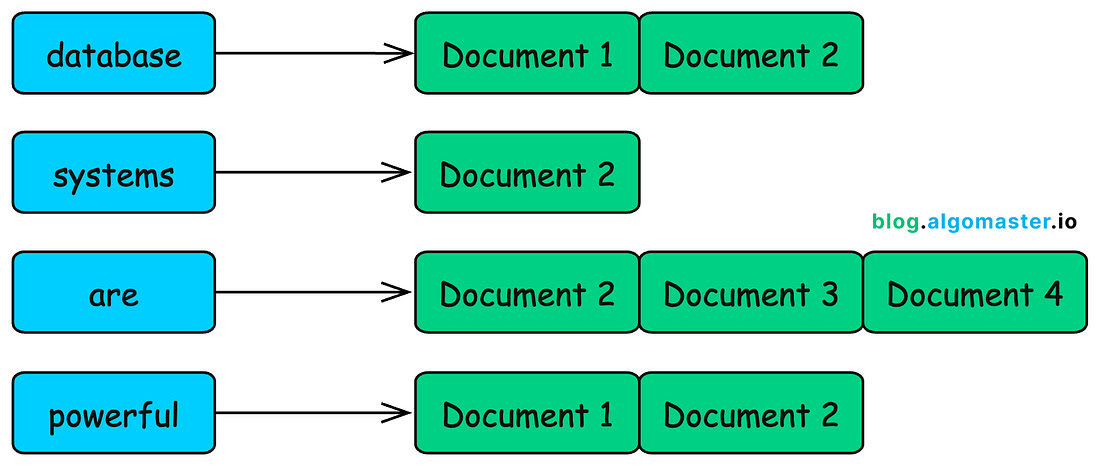

#### When to use it
1. You need fast, flexible search over text: Full-text search databases are built to index and query large volumes of unstructured or semi-structured text quickly and accurately.
2. You want ranked or fuzzy search: Text-search databases support intelligent matching, even when the query isn’t exact. They handle typos, variations, and synonyms for a smoother user experience.
3. You need search plus structured filtering: Text-search engines support combining keyword relevance with filters like location, price, or categories.

#### Design Considerations
1. Inverted Indexing: Instead of storing data row-by-row like a typical database, text-search engines build an inverted index—a data structure that maps terms (words) to the documents they appear in.
2. Tokenization & Stemming: Before indexing, search engines tokenize the text (split it into individual words) and often apply stemming or lemmatization to reduce words to their root form.
3. Relevance Scoring: Text-search engines don’t just match documents, they rank them by relevance using scoring algorithms like TF-IDF or BM25.
4. Scalability: Many modern text-search engines (like Elasticsearch, OpenSearch, and Solr) support horizontal scaling, distributed indexing, sharding, and replication for high availability and performance.

#### Example Databases
1. Elasticsearch – Most popular open-source full-text search engine, widely used across industries
2. Apache Solr – Enterprise-grade search platform based on Lucene

### Spatial
A Spatial Database is designed to store and query geospatial data—information about locations, shapes, distances, and coordinates on Earth. It supports complex spatial operations like proximity search, intersection, bounding box queries, and geofencing.

#### When to use it
1. Your system uses location-based features: Spatial database are ideal for apps that store and query real-world locations.
2. You need to store and query shapes or regions: Spatial databases handle geometric operations like contains, intersects, and within.

#### Design Considerations
1. Spatial Indexing: Spatial databases optimize spatial queries using specialized indexing structures like:

-> R-Trees – Ideal for range queries and bounding box searches

-> QuadTrees – Useful for dividing 2D space into quadrants, good for sparse data

-> Geohashing – Converts latitude/longitude into hash strings, enabling prefix-based lookups and distributed sharding

2. Accuracy vs Performance: For performance reasons, many spatial systems use approximations such as:
Bounding boxes instead of exact polygons, Radius-based filtering instead of full geodistance calculations

These are often good enough for user-facing features (e.g., "cafes near me") but may not be suitable for mission-critical use cases like aviation, navigation, or legal land boundaries.

3. Scalability: Spatial queries are compute-intensive. To scale: Use indexes on geo fields, Cache frequently queried regions, Limit search scope (e.g., within a city)

4. Integrations: You may not need a dedicated spatial DB. Many databases offer built-in or extended spatial support: PostgreSQL + PostGIS, MongoDB (2D and spherical indexes), Elasticsearch (geo-distance and geo-shape queries)

#### Example databases
1. PostGIS – Spatial extension for PostgreSQL, widely used for GIS applications
2. MongoDB – Supports geospatial indexes and queries out of the box
3. Google BigQuery GIS – Supports large-scale spatial analysis on cloud
4. ElasticSearch – Offers location-based search with geo-distance and geo-shape filters

### Blob Store
A Blob Store is a storage system optimized for handling large, unstructured binary files like images, videos, PDFs, backups, or logs. Instead of storing content in rows and columns, it stores it as binary blobs and uses metadata (like filenames or upload timestamps) for retrieval.

#### When to use it
1. You need to store large media files: Blob stores are optimized for storing and serving binary files like images, videos, and audio at scale.
2. The data doesn’t fit a traditional database: Relational and NoSQL databases are designed for structured data, not for storing massive binary payloads. Blob storage is a better fit when you're dealing with documents or file-based assets that aren’t meant to be queried or filtered by content.
3. You want scalable, low-cost storage: Blob stores offer pay-as-you-go storage, automatic replication, and built-in durability making them ideal for storing large volumes of cold or rarely accessed data.

#### Design Considerations
1. Metadata Manegement: Blob stores typically don’t support querying metadata. Store metadata (e.g., uploader, upload time) in a database, linked by the blob’s key or filename.
2. Access control: Blob stores typically do not have built-in user authentication or fine-grained permission systems. You'll need to handle access control explicitly to prevent unauthorized access.Common strategies include:
-> Signed URLs for time-limited access
-> Token-based access tied to user permissions
-> IAM policies at the bucket or object level

3. Chunking large files: Uploading or downloading large files (e.g., videos, high-res images) can fail or time out if done in a single request. Blob storage platforms support chunked or multi-part uploads, which split files into smaller parts.
This improves reliability, performance and supports resuming if a transfer fails midway.

4. Scalability and Durability: Blob stores like Amazon S3 are designed to scale almost infinitely, handling billions of files and petabytes of data with: Automatic replication across multiple availability zones, Up to 11 nines (99.999999999%) durability

5. CDN Integration: To reduce latency and improve performance for end users, especially in media-heavy applications, integrate your blob store with a Content Delivery Network (CDN) like CloudFront or Cloudflare. CDN caches content closer to users reducing load on your origin blob store and speeding up delivery of large assets like images and videos.

#### Example Databases
1. Amazon S3 – Industry standard for blob storage, with versioning, encryption, and lifecycle rules
2. Google Cloud Storage – Scalable and secure object storage on GCP
3. Azure Blob Storage – Microsoft’s equivalent for storing large unstructured data